In [1]:
"""

@author: Gabriel Turinici 2025
"""

"""
This program uses historical data in the format in :
    https://turinici.com/wp-content/uploads/cours/common/close_cac40_historical.csv

It can also be downloaded form yahoo finance in daily
prices (at least the "close") if possible at lest 5 years

Idea: use yahoo e.g., yfinance package
"pip install yfinance"


Then the code does :

1'/ order by increasing date
2/ plot price histogram and returns  (with "log" and/or "actuarial")
3/ test normality of : prices, log returns, actuarial returns
    for instance can use scipy.stats.normaltest
4/ shows the random versus optimal results
5/ show what a backtest would obtain : compute market portfolio from T-6Y,T-1Y data
(last 5 years of data before this last year)
6/ compute performance of estimated market portfolio on the T-1Y,T data (last year data)
7/ compare with random choices

"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kstest, normaltest

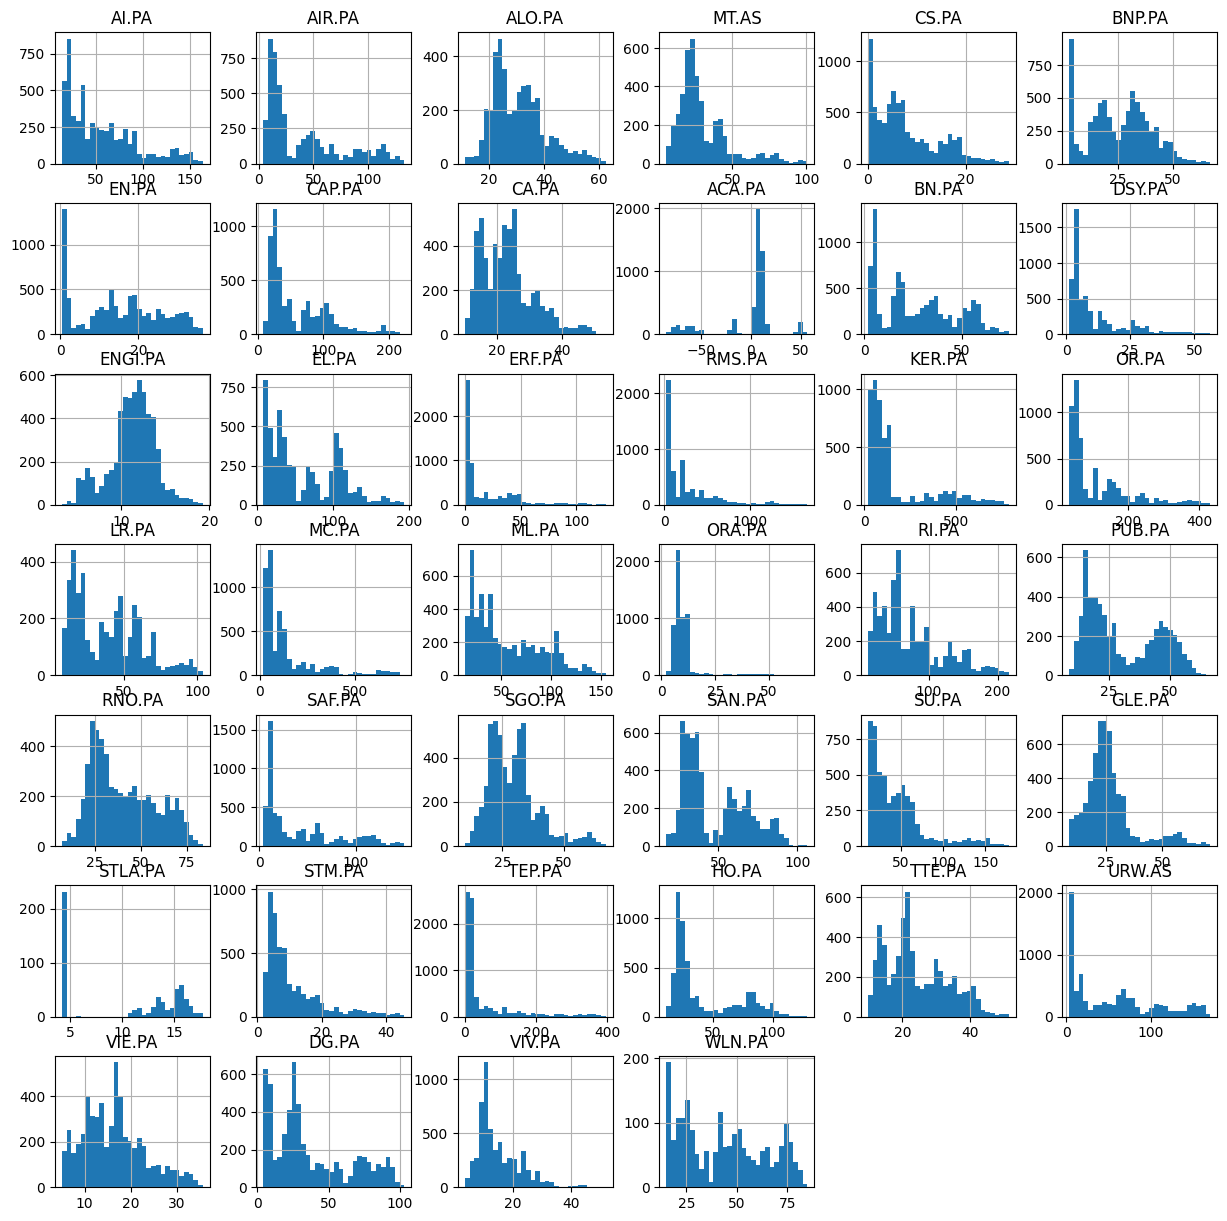

In [2]:
# from scipy.special import softmax

# take csv from www course :we suppose it is available locally
data = pd.read_csv(
    "https://turinici.com/wp-content/uploads/cours/common/close_cac40_historical.csv",
    sep=";",
    index_col="Date",
)
data.head()
# order by increasing date, keep variable 'data'
data.sort_index(ascending=True, inplace=True)
# data.sort(by='Date',inplace=True)
data.head()
data.tail()

# plot histogram of prices
_ = data.hist(bins=30, figsize=(15, 15))

In [ ]:
def normality_test(data, kolmogorov_smirnov=False, level=0.01, print_results=True):
    """
    Tests normality of each column of dataframe "data".
    Inputs:
        kolmogorov_smirnov= false: use "normaltest", otherswise use kstest, both from scipy.stats
        level = p-value threshold level for the conclusions

    Outputs:  the number of yes/no in the results
    """
    pvalues = []
    for cols in data.keys():
        pv = (
            kstest(data[cols].dropna(), "norm").pvalue
            if kolmogorov_smirnov
            else normaltest(data[cols].dropna()).pvalue
        )
        pvalues.append(pv)
        if pv < level:
            res = "not normal"
        else:
            res = "normal"
        print("Test pval=", pv, "res=", res)
    normalok = sum([1 for pv in pvalues if pv >= level])
    normalnotok = sum([1 for pv in pvalues if pv < level])
    if print_results:
        print("no. of normal = ", normalok)
        print("no. of not normal = ", normalnotok)
    return normalok, normalnotok


normality_test(data)

Test pval= 2.0507269291153243e-147 res= not normal
Test pval= 1.2341507304168457e-145 res= not normal
Test pval= 1.5109663099066784e-82 res= not normal
Test pval= 5.193407329538019e-261 res= not normal
Test pval= 9.263758145504221e-171 res= not normal
Test pval= 1.5679377988996054e-95 res= not normal
Test pval= 0.0 res= not normal
Test pval= 3.431480107389548e-229 res= not normal
Test pval= 7.209347413730216e-130 res= not normal
Test pval= 5.208576684311371e-248 res= not normal
Test pval= 0.0 res= not normal
Test pval= 0.0 res= not normal
Test pval= 6.226583000372112e-32 res= not normal
Test pval= 2.8139918420327365e-122 res= not normal
Test pval= 0.0 res= not normal
Test pval= 0.0 res= not normal
Test pval= 0.0 res= not normal
Test pval= 0.0 res= not normal
Test pval= 3.2023586082752444e-62 res= not normal
Test pval= 0.0 res= not normal
Test pval= 2.3734732069569748e-122 res= not normal
Test pval= 0.0 res= not normal
Test pval= 3.658142667687734e-131 res= not normal
Test pval= 0.0 res

(0, 40)

/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Test pval= 0.025428757930302828 res= normal
Test pval= 0.01412845580561908 res= normal
Test pval= 0.2844927942646553 res= normal
Test pval= 0.2807546954064213 res= normal
Test pval= 0.009428521835360353 res= not normal
Test pval= 0.14982216104037197 res= normal
Test pval= 0.07490385366598394 res= normal
Test pval= 0.1693491210857498 res= normal
Test pval= 0.00622835412057237 res= not normal
Test pval= 0.0038601712111598595 res= not normal
Test pval= 0.00014234445964435524 res= not normal
Test pval= 0.1559244997516793 res= normal
Test pval= 5.4492134141853295e-12 res= not normal
Test pval= 0.027428045061480538 res= normal
Test pval= 0.00011538203750856845 res= not normal
Test pval= 0.07350032657006557 res= normal
Test pval= 0.10474460687572516 res= normal
Test pval= 0.0015506993297124128 res= not normal
Test pval= 0.36679129167153646 res= normal
Test pval= 0.011263558096640853 res= normal
Test pval= 1.4403372640862255e-05 res= not normal
Test pval= 0.017985610179734428 res= normal
Test 

(26, 14)

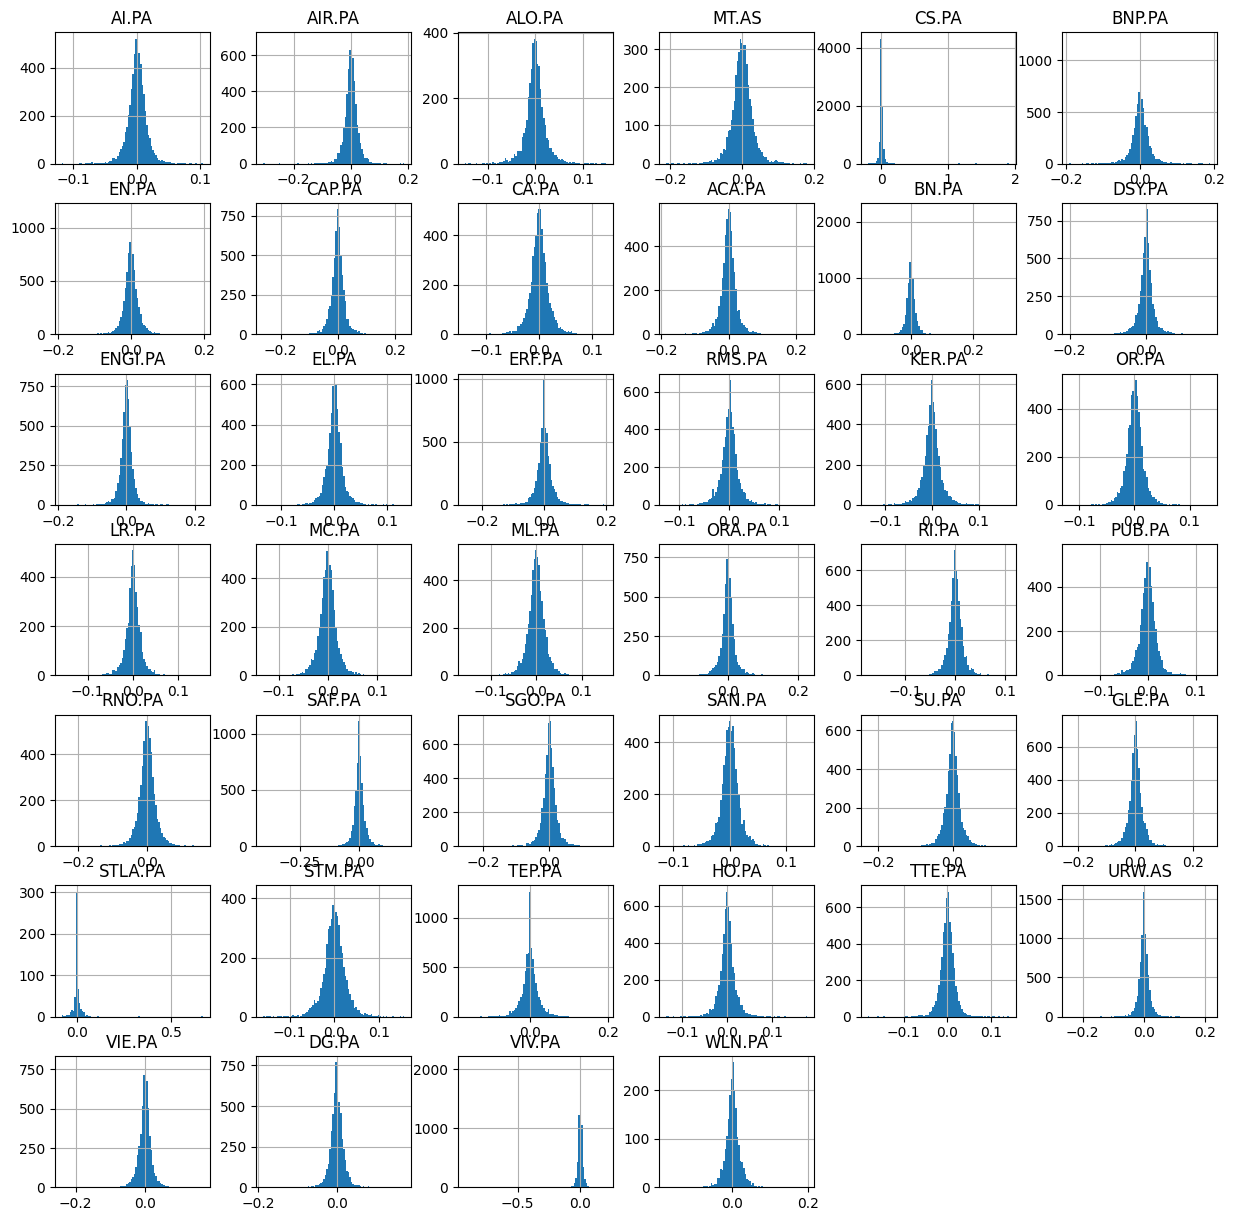

In [ ]:
# use 'data' to compute returns
# returns= data.pct_change() #actuarial
returns = np.log(data / data.shift(1))

nr_days = 252

# print('annualize returns')
# returns *= nr_days

_ = returns.hist(bins=int(np.sqrt(returns.shape[0])), figsize=(15, 15))

normality_test(returns.tail(25 * 3))   # test last 3 months

normality tests for increments, not returns!!
Test pval= 0.08683895238128052 res= normal
Test pval= 0.021035773553864635 res= normal
Test pval= 0.38286247315996325 res= normal
Test pval= 0.3710853667901102 res= normal
Test pval= 0.0395519075986371 res= normal
Test pval= 0.26910192261508514 res= normal
Test pval= 0.11094121314729449 res= normal
Test pval= 0.3180825721276856 res= normal
Test pval= 0.011858172793204136 res= normal
Test pval= 0.008952882580561775 res= not normal
Test pval= 0.0008467555154087856 res= not normal
Test pval= 0.2098816393496899 res= normal
Test pval= 5.524153122423706e-14 res= not normal
Test pval= 0.15309417383852073 res= normal
Test pval= 0.0010024995182926846 res= not normal
Test pval= 0.3549281579113689 res= normal
Test pval= 0.3129404747848908 res= normal
Test pval= 0.008997473704571489 res= not normal
Test pval= 0.6147399643675131 res= normal
Test pval= 0.09700094185831638 res= normal
Test pval= 0.00118024612616608 res= not normal
Test pval= 0.01009373392

(31, 9)

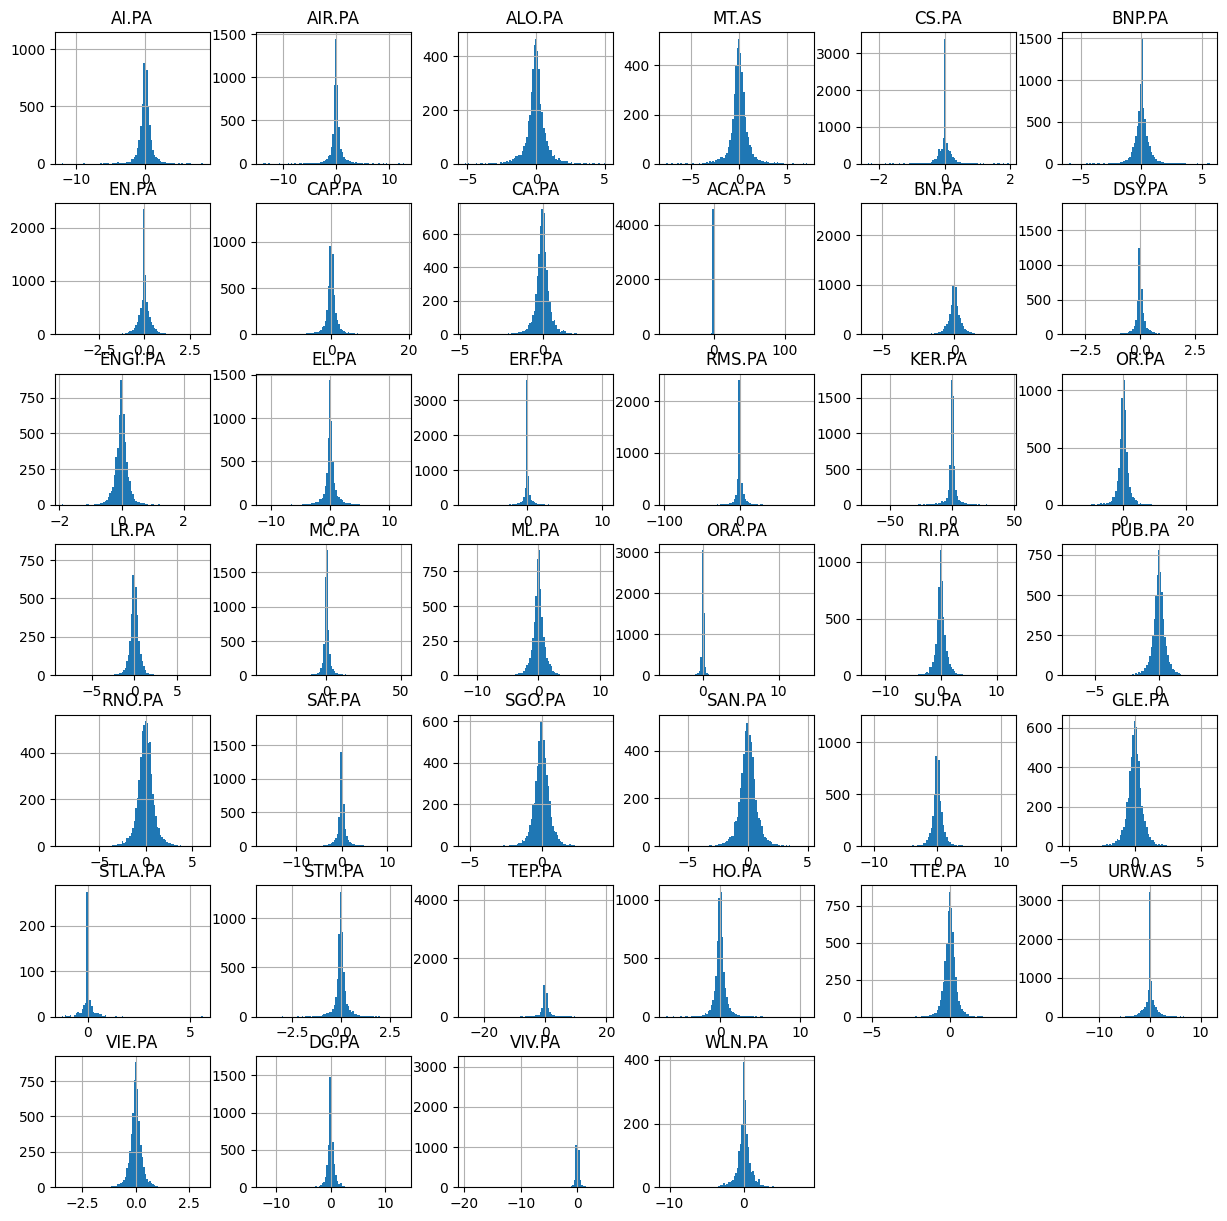

In [5]:
print("normality tests for increments, not returns!!")
increments = data - data.shift(1)
_ = increments.hist(bins=int(np.sqrt(increments.shape[0])), figsize=(15, 15))

normality_test(increments.tail(25 * 3))

In [ ]:
nb = 15  # will work with nb stocks
all_returns = returns.copy()  # backup
nb_all = all_returns.shape[1]

if nb > nb_all:
    print("too many number of stocks, revert to max")
    nb = nb_all

# choose the stock names
nb_stocks_names = np.random.choice(all_returns.keys(), nb, replace=False)
returns_small = all_returns.loc[:, nb_stocks_names]

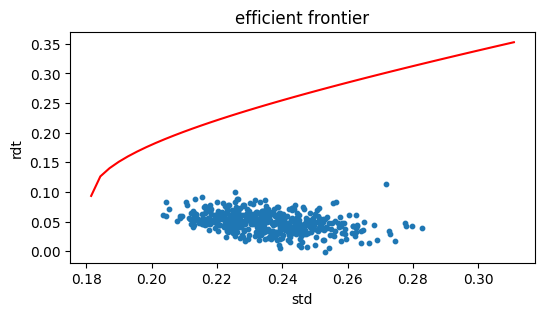

In [12]:
mean_returns = returns_small.mean()
cov_matrix = returns_small.cov()
rdt_list = []
std_list = []

for _ in range(500):
    # sample at random some "allocation"
    allocation = np.random.dirichlet(np.ones(nb))
    rdt_port = allocation @ mean_returns
    std_port = np.sqrt(allocation @ cov_matrix @ allocation)
    rdt_list.append(rdt_port)
    std_list.append(std_port)

std_list = np.array(std_list)
rdt_list = np.array(rdt_list)

inverse_cov = np.linalg.inv(cov_matrix)

# compute and draw the efficient frontier on the same graph
onesM = np.ones_like(mean_returns)

# compute 'a' and 'b' using formulas from the course
a = onesM @ inverse_cov @ onesM  # np.sum(inverse_cov)
b = onesM @ inverse_cov @ mean_returns

# plot the frontier and its symmetric w/r to origin
sigmarange = np.linspace(1.0 / np.sqrt(a) + 1.0e-10, 1.1 * np.max(std_list), 47)
# compute the return of the optimal portfolio for sigma in sigmarange
# will use the "factor" auxiliary variable
factor = np.sqrt((mean_returns - b / a) @ inverse_cov @ (mean_returns - b / a))
optimal_return = b / a + np.sqrt(sigmarange**2 - 1.0 / a) * factor

fig = plt.figure("perf", figsize=(6, 3))
plt.title("efficient frontier")
plt.scatter(std_list * np.sqrt(nr_days), rdt_list * nr_days, s=10)
plt.plot(sigmarange * np.sqrt(nr_days), optimal_return * nr_days, "r-")
plt.xlabel("std")
plt.ylabel("rdt")
plt.show()
plt.close()

TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

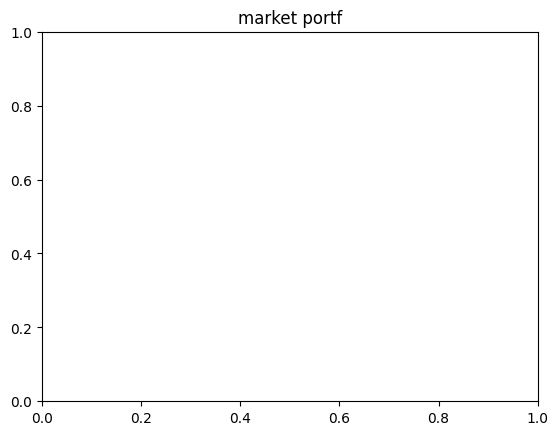

In [ ]:
# plot market portfolio
r_rate = 0.0  # attention to convert to daily (not annualize!) if not zero !!!
market_portf_allocation = None

plt.title("market portf")
plt.bar(list(range(1, 1 + nb)), market_portf_allocation)
plt.show()
plt.close()
np.sum(np.abs(market_portf_allocation)) * 100

# test on data obtained from T-6Y,T-1Y the rdv/vol on T-1Y,T
# and compare with market portfolio on T-1,T. T=last known date

# calcul of mean_returns and inverse_cov between T-6Y and T-1Y, 1Y=255 days
ti = -6 * 255
tf = -255
hist_mean_returns = returns_small.iloc[ti:tf, :].mean()
hist_cov_matrix = returns_small.iloc[ti:tf, :].cov()
hist_inverse_cov = np.linalg.inv(hist_cov_matrix)
hist_market_portf_allocation = None

plt.title("estimated market portf")
plt.bar(list(range(1, 1 + nb)), hist_market_portf_allocation)
plt.show()
plt.close()

# compute performance during T-1Y,T
c_mean_returns = None
c_cov_matrix = None
c_inverse_cov = np.linalg.inv(c_cov_matrix)

rdt_backtest = None
std_backtest = None

np.sqrt(hist_market_portf_allocation @ c_inverse_cov @ hist_market_portf_allocation)

print(
    f"Annualized rdt_backtest: {rdt_backtest * (nr_days) * 100:.2f}%, std_backtest:{std_backtest * np.sqrt(nr_days):.2f}%"
)

In [ ]:
nr_tests = 500
c_rdt_list = np.zeros((nr_tests,))
c_std_list = np.zeros((nr_tests,))

for ii in range(nr_tests):
    # sample at random some "allocation"
    allocation = np.random.dirichlet(np.ones(nb))
    c_rdt_list[ii] = allocation @ c_mean_returns  
    c_std_list[ii] = np.sqrt(allocation @ c_cov_matrix @ allocation)  

# reduce to target volatility (the mean of random ones)
target_vol = np.mean(std_list * np.sqrt(nr_days))

reduction_factor = target_vol / np.sqrt(nr_days) / std_backtest
reduced_hist_allocation = reduction_factor * hist_market_portf_allocation
reduced_rdt_backtest = reduced_hist_allocation @ c_mean_returns
reduced_std_backtest = np.sqrt(
    reduced_hist_allocation @ c_inverse_cov @ reduced_hist_allocation
)

fig = plt.figure("perf last backtest")
plt.scatter(c_std_list * np.sqrt(nr_days), c_rdt_list * nr_days, s=10, label="random")
plt.scatter(
    reduced_std_backtest * np.sqrt(nr_days),
    reduced_rdt_backtest * nr_days,
    marker="*",
    label="backtest",
)
plt.xlabel("std")
plt.ylabel("rdt")
plt.legend()
plt.show()
plt.close()


NameError: name 'c_mean_returns' is not defined